In [23]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

In [14]:
class ValueNet(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class PolicyNet(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=-1)


In [29]:
def compute_advantage(gamma, lmbda, td_deltas):
    td_deltas = td_deltas.view(-1)
    advantages = []
    cur_advantage = 0
    for i in reversed(range(len(td_deltas))):
        cur_advantage = gamma * lmbda * cur_advantage + td_deltas[i]
        advantages.append(cur_advantage)
    return torch.tensor(list(reversed(advantages)), dtype=torch.float)

In [33]:
class PPO:
    def __init__(self, state_dim, hidden_dim, action_dim, actor_lr, critic_lr, epochs, gamma, lmbda, eps, device):
        self.actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
        self.critic = ValueNet(state_dim, hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.epochs = epochs
        self.gamma = gamma
        self.lmbda = lmbda
        self.eps = eps
        self.device = device

    def take_action(self, state):
        state = torch.tensor(state, dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        return action_dist.sample().item()

    def update(self, transition_dict):
        states = torch.tensor(np.array(transition_dict['states']), dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.long).view(-1, 1).to(self.device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(np.array(transition_dict['next_states']), dtype=torch.float).to(self.device)
        terminated = torch.tensor(transition_dict['terminated'], dtype=torch.float).view(-1, 1).to(self.device)

        td_targets = rewards + self.gamma * self.critic(next_states) * (1 - terminated)
        td_deltas = td_targets - self.critic(states)
        advantages = compute_advantage(self.gamma, self.lmbda, td_deltas).view(-1, 1).to(self.device)
        # Use log probs for numerical stability
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach()

        for _ in range(self.epochs):
            log_probs = torch.log(self.actor(states).gather(1, actions))
            weights = torch.exp(log_probs - old_log_probs)
            surr1 = weights * advantages
            surr2 = torch.clamp(weights, 1 - self.eps, 1 + self.eps) * advantages
            actor_loss = -torch.mean(torch.min(surr1, surr2))
            critic_loss = F.mse_loss(self.critic(states), td_targets.detach())

            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            actor_loss.backward()
            critic_loss.backward()
            self.actor_optimizer.step()
            self.critic_optimizer.step()


In [38]:
num_episodes = 300
hidden_dim = 128
actor_lr = 1e-3
critic_lr = 1e-2
epochs = 10
gamma = 0.98
lmbda = 0.95
eps = 0.2
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

env_name = 'CartPole-v1'
env = gym.make(env_name)

env.reset(seed=0)
torch.manual_seed(0)
np.random.seed(0)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = PPO(state_dim, hidden_dim, action_dim, actor_lr, critic_lr, epochs, gamma, lmbda, eps, device)

return_list = []
for i in range(10):
    with tqdm(total= num_episodes // 10, desc='Iteration %d' % i) as pbar:
        for i_episode in range(num_episodes // 10):
            state, info = env.reset()
            transition_dict = defaultdict(list)
            episode_return = 0

            while True:
                action = agent.take_action(state)
                next_state, reward, terminated, truncated, info = env.step(action)
                episode_return += reward

                transition_dict['states'].append(state)
                transition_dict['actions'].append(action)
                transition_dict['rewards'].append(reward)
                transition_dict['next_states'].append(next_state)
                transition_dict['terminated'].append(terminated)

                if terminated or truncated:
                    break
                state = next_state

            agent.update(transition_dict)
            return_list.append(episode_return)

            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode': '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return': '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)


Iteration 9: 100%|██████████| 30/30 [00:32<00:00,  1.08s/it, episode=300, return=500.000]


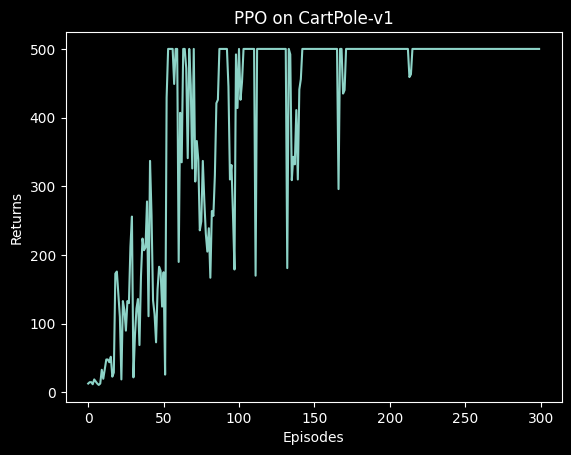

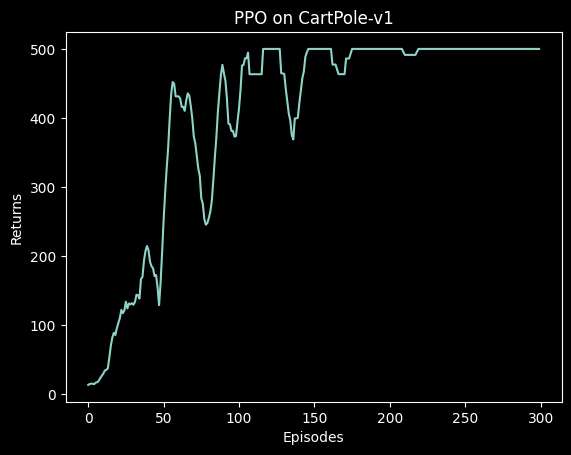

In [39]:
episode_list = list(range(len(return_list)))
plt.plot(episode_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on CartPole-v1')
plt.show()

def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0))
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size

    r = np.arange(1, window_size, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

mv_return = moving_average(return_list, 9)
plt.plot(episode_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('PPO on CartPole-v1')
plt.show()
